In [1]:
import numpy as np
from scipy.stats import wishart, t
from explainer.MMDExplainer import MMDExplainer
import seaborn as sns
import shap

import matplotlib.pyplot as plt

/Users/Moham079/surfdrive/Research/ExplainableAI/RKHSExactSHAP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


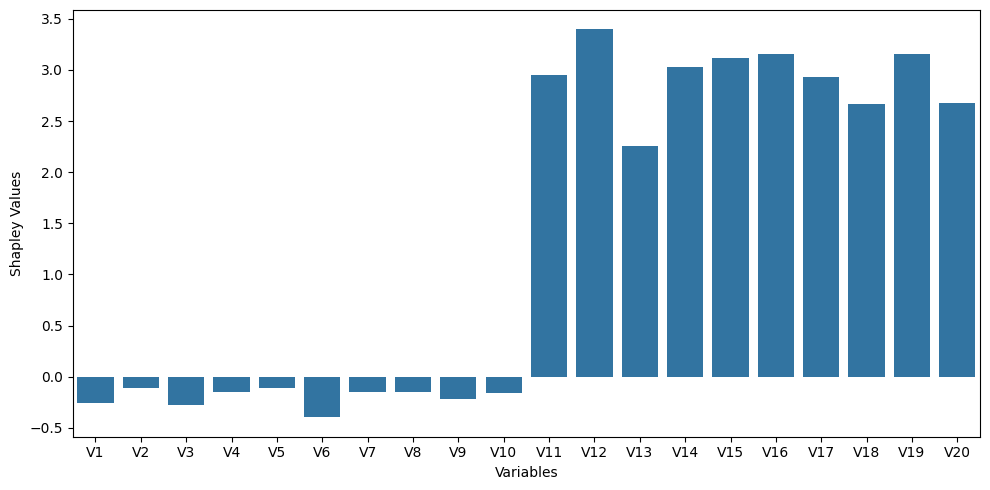

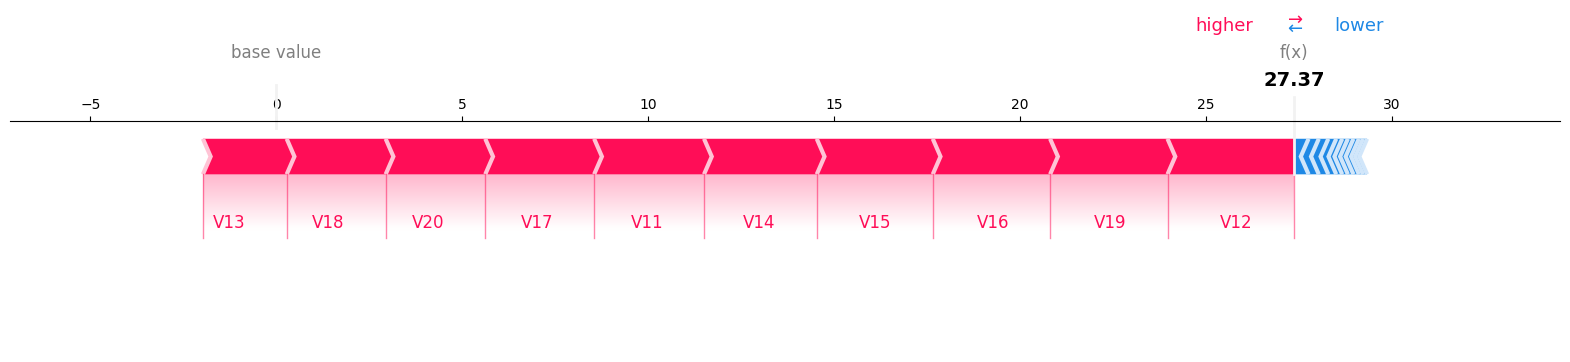

In [5]:

# Set parameters
d = 20 # Total number of variables
d_prime = 10 # Number of variables in the first group
n_samples = 2000
mode = 'indepedent'

# Generate the covariance matrix for the first d' features
wishart_df1 = d_prime
wishart_scale1 = np.eye(d_prime)
cov1 = wishart.rvs(df=wishart_df1, scale=wishart_scale1, size=1)

if mode == 'indepedent':
    cov1 = np.eye(d_prime)

mean1 = np.zeros(d_prime)
X1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=n_samples)
mean2 = np.zeros(d - d_prime)
X2 = np.random.multivariate_normal(mean=mean2, cov=np.eye(d-d_prime), size=n_samples)
X = np.hstack((X1, X2))

Z1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=n_samples)
Z2_mean = np.mean(X2, axis=0)
Z2_std = np.std(X2, axis=0)
Z2 = t.rvs(df=3, loc=Z2_mean, scale=Z2_std, size=(n_samples, d - d_prime))
Z = np.hstack((Z1, Z2))

explainer = MMDExplainer(X=X, Z=Z, value_function="baseline")
sv = explainer.explain()

variables = [f"V{i}" for i in range(1, d+1)]
sv_statistics = n_samples * np.array(sv)

# Barplot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=variables, y=sv_statistics)
ax.set_xlabel("Variables")
ax.set_ylabel("Shapley Values")
plt.tight_layout()
plt.show()

# SHAP force plot style
shap.initjs()
shap_values = sv_statistics
base_value = 0
shap.force_plot(base_value, shap_values, feature_names=variables, matplotlib=True)